In [ ]:
!pip install --upgrade protobuf tensorflow-metadata tensorflow-datasets

In [ ]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import cv2
import numpy as np
import shutil

base_dir = '/content/dataset_industrial_limto'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.makedirs(os.path.join(base_dir, 'person'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'no-person'), exist_ok=True)

print(" Baixando subset oficial do Pascal VOC (Validado Cientificamente)...")
ds_bruto, info = tfds.load('voc/2012', split='train+validation', with_info=True)

count_p = 0
count_np = 0
limite_imagens = 400

print("✂️ Filtrando e extraindo apenas a categoria 'person'...")
for exemplo in ds_bruto:
    imagem_tensor = exemplo['image']
    objetos_classes = exemplo['objects']['label'].numpy()

    tem_pessoa = 14 in objetos_classes

    img_np = imagem_tensor.numpy()
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    if tem_pessoa and count_p < (limite_imagens // 2):
        nome_arquivo = f"person_{count_p}.jpg"
        cv2.imwrite(os.path.join(base_dir, 'person', nome_arquivo), img_bgr)
        count_p += 1
    elif not tem_pessoa and count_np < (limite_imagens // 2):
        nome_arquivo = f"no_person_{count_np}.jpg"
        cv2.imwrite(os.path.join(base_dir, 'no-person', nome_arquivo), img_bgr)
        count_np += 1

    if count_p >= (limite_imagens // 2) and count_np >= (limite_imagens // 2):
        break

print(f"\n Dataset criado com sucesso e 100% livre de erros humanos!")
print(f"-> Imagens com Pessoas Reais (Garantido): {count_p}")
print(f"-> Imagens de Ambientes Vazios (Garantido): {count_np}")

📥 Baixando subset oficial do Pascal VOC (Validado Cientificamente)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.A7FGE8_5.0.0/voc-train.tfrecord-[0-9][0-9][0-9][0-9][0…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.A7FGE8_5.0.0/voc-validation.tfrecord-[0-9][0-9][0-9][0…

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
✂️ Filtrando e extraindo apenas a categoria 'person'...

 Dataset criado com sucesso e 100% livre de erros humanos!
-> Imagens com Pessoas Reais (Garantido): 200
-> Imagens de Ambientes Vazios (Garantido): 200


In [ ]:
import tensorflow as tf

# ==========================================
# 1. DATASET COM 96x96
# ==========================================
IMG_SIZE = (96, 96)  # <- mudou aqui
BATCH_SIZE = 32
novo_base_dir = '/content/dataset_industrial_limto'

train_ds = tf.keras.utils.image_dataset_from_directory(
    novo_base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    novo_base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# ==========================================
# 2. MODELO COM MOBILENETV2 alpha=0.35
# ==========================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet',
    alpha=0.35
)
base_model.trainable = False  # congela pra fase 1

inputs = tf.keras.Input(shape=(96, 96, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_tl = tf.keras.Model(inputs, outputs)
model_tl.summary()

Found 400 files belonging to 2 classes.
Using 320 files for training.
Found 400 files belonging to 2 classes.
Using 80 files for validation.
2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,489 (1.57 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

## Inspeção de Formato e Visualização de Amostras Reais
Verificamos as dimensões das matrizes geradas pelo TensorFlow e printamos as primeiras 8 imagens para garantir visualmente que o dataset está correto e sem erros de rótulo.

The image data batch shape is: (#images_per_batch, img_height, img_width, #channels)
-> Imagens de Treino: (32, 96, 96, 3)

The labels batch shape is: (#images_per_batch, binary_target)
-> Rótulos de Treino: (32, 1)

 Exibindo amostras do novo lote (Garantido livre de erros):


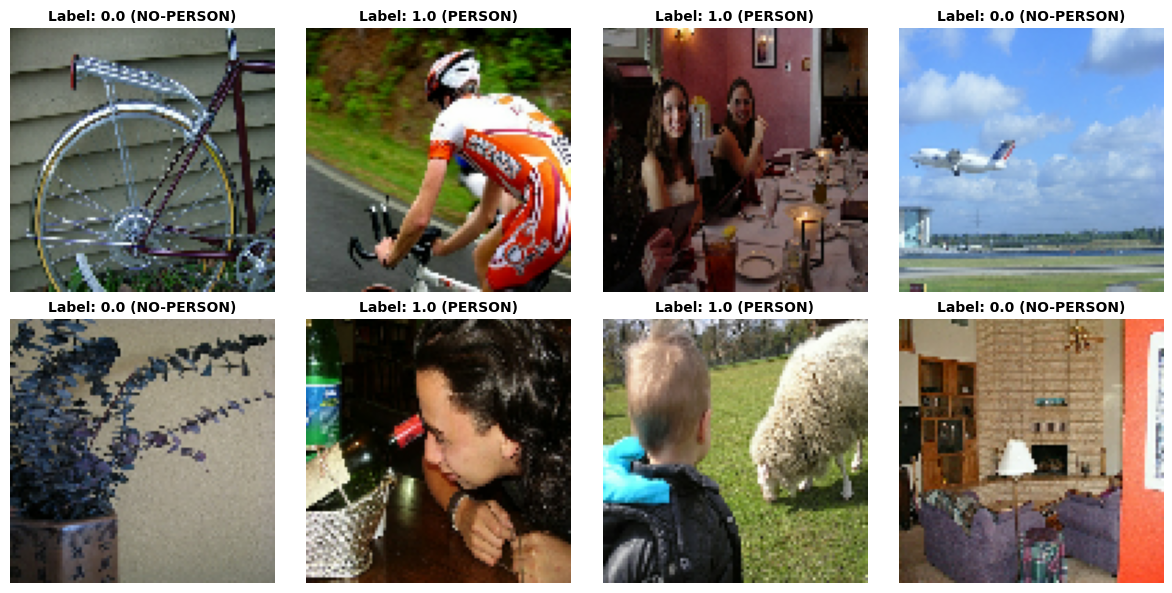

In [ ]:
import matplotlib.pyplot as plt

class_names_bin = {0.0: "no-person", 1.0: "person"}

for imagens_lote, labels_lote in train_ds.take(1):
    shape_imagens_treino = imagens_lote.shape
    shape_labels_treino = labels_lote.shape

print("The image data batch shape is: (#images_per_batch, img_height, img_width, #channels)")
print(f"-> Imagens de Treino: {shape_imagens_treino}")
print("\nThe labels batch shape is: (#images_per_batch, binary_target)")
print(f"-> Rótulos de Treino: {shape_labels_treino}\n")

print(" Exibindo amostras do novo lote (Garantido livre de erros):")
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)

    img_render = imagens_lote[i].numpy().astype("uint8")
    label_val = labels_lote[i].numpy()[0]

    plt.imshow(img_render)
    plt.title(f"Label: {label_val} ({class_names_bin[label_val].upper()})", fontsize=10, weight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Arquitetura da Rede Neural (Transfer Learning)
Instanciamos a MobileNetV2 congelada, adicionamos o bloco avançado de Data Augmentation para simular variações de luz/contraste do ambiente industrial e estruturamos o topo denso da rede.

In [ ]:
from tensorflow.keras import layers, models, applications

# Camada de Input
inputs = layers.Input(shape=(96, 96, 3))

# DATA AUGMENTATION
x = layers.RandomFlip("horizontal")(inputs) # Ajuda se a pessoa estiver virada para o outro lado
x = layers.RandomRotation(0.15)(x)         # Ajuda se a câmera ou a pessoa estiverem inclinadas
x = layers.RandomZoom(0.2)(x)             # Força a rede a aprender a ver pessoas de longe e de perto
x = layers.RandomContrast(0.2)(x)         # Cria variações de sombra e iluminação artificial

# Pré-processador nativo da MobileNetV2
x = applications.mobilenet_v2.preprocess_input(x)

# Modelo Base
base_model = applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3),
    alpha=0.35
)
base_model.trainable = False
x = base_model(x, training=False)

# Cabeça de Classificação
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_tl = models.Model(inputs, outputs)
model_tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 96, 96, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,305 (2.19 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

## 7. Processo de Treinamento e Fine-Tuning
Executamos o treinamento em duas etapas: primeiro o Warm-up das camadas densas superiores, seguido pelo descongelamento das últimas 20 camadas convolucionais da MobileNetV2 com uma taxa de aprendizado reduzida.

In [ ]:
# ==========================================
# CONFIGURAÇÃO DA FASE 1 (Warm-up)
# ==========================================
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
)

callback_fase1 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Fase 1: Ajustando camadas de classificação superiores...")
history_fase1 = model_tl.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=[callback_fase1])


# ==========================================
# CONFIGURAÇÃO DA FASE 2 (Fine-Tuning)
# ==========================================
print("\nDestravando apenas as últimas 5 camadas finais para especialização industrial...")
base_model.trainable = True

for layer in base_model.layers[:-5]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
)

callback_fase2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("Fase 2: Iniciando Fine-Tuning profundo...")
history_fase2 = model_tl.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[callback_fase2])

Fase 1: Ajustando camadas de classificação superiores...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 259ms/step - accuracy: 0.5781 - loss: 0.8578 - val_accuracy: 0.7000 - val_loss: 0.5371
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7188 - loss: 0.6560 - val_accuracy: 0.7625 - val_loss: 0.4934
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7000 - loss: 0.6159 - val_accuracy: 0.8000 - val_loss: 0.4776
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7188 - loss: 0.5595 - val_accuracy: 0.7750 - val_loss: 0.4721
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7531 - loss: 0.5238 - val_accuracy: 0.7875 - val_loss: 0.4698

Destravando apenas as últimas 5 camadas finais para especialização industrial...
Fase 2: Iniciando Fine-Tuning profundo...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - accuracy: 0.7312 - loss: 0.5464 - val_accuracy: 0.8000 - val_loss: 0.4666
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accur

## Performance Curve Charts
Exibimos a evolução histórica das métricas de Acurácia e Perda ao longo das épocas computacionais processadas.

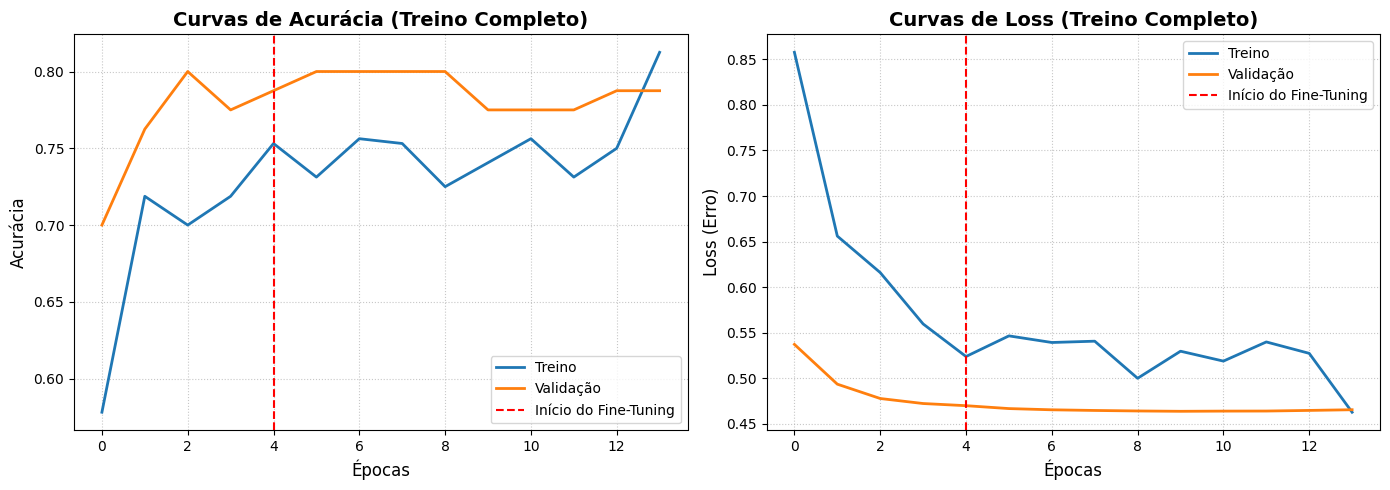

In [ ]:
import matplotlib.pyplot as plt

# 1. Juntando as métricas das duas fases
acc = history_fase1.history['accuracy'] + history_fase2.history['accuracy']
val_acc = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']

loss = history_fase1.history['loss'] + history_fase2.history['loss']
val_loss = history_fase1.history['val_loss'] + history_fase2.history['val_loss']

# Época exata onde ocorreu a transição para marcar no gráfico
epoca_transicao = len(history_fase1.history['accuracy']) - 1

# 2. Plotando o Gráfico Científico
plt.figure(figsize=(14, 5))

# Curva de Acurácia
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino', linewidth=2, color='#1f77b4')
plt.plot(val_acc, label='Validação', linewidth=2, color='#ff7f0e')
plt.axvline(x=epoca_transicao, color='red', linestyle='--', label='Início do Fine-Tuning')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Curvas de Acurácia (Treino Completo)', fontsize=14, weight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# Curva de Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino', linewidth=2, color='#1f77b4')
plt.plot(val_loss, label='Validação', linewidth=2, color='#ff7f0e')
plt.axvline(x=epoca_transicao, color='red', linestyle='--', label='Início do Fine-Tuning')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss (Erro)', fontsize=12)
plt.title('Curvas de Loss (Treino Completo)', fontsize=14, weight='bold')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Statistical Model Evaluation
Extraímos a matriz de confusão e o relatório discriminado por classe para aferir o poder preditivo final do classificador binário industrial.


--- MATRIZ DE CONFUSÃO BRUTA ---
[[28 10]
 [ 8 34]]

--- RELATÓRIO DE CLASSIFICAÇÃO INDUSTRIAL ---
              precision    recall  f1-score   support

   no-person       0.78      0.74      0.76        38
      person       0.77      0.81      0.79        42

    accuracy                           0.78        80
   macro avg       0.78      0.77      0.77        80
weighted avg       0.78      0.78      0.77        80



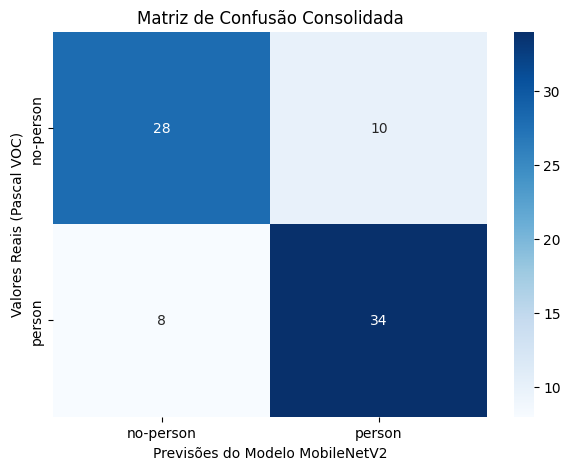

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model_tl.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())

print("\n--- MATRIZ DE CONFUSÃO BRUTA ---")
matriz = confusion_matrix(np.array(y_true), np.array(y_pred))
print(matriz)

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO INDUSTRIAL ---")
print(classification_report(np.array(y_true), np.array(y_pred), target_names=['no-person', 'person']))

plt.figure(figsize=(7, 5))
sns.heatmap(matriz, cmap='Blues', annot=True, fmt='g',
            xticklabels=['no-person', 'person'],
            yticklabels=['no-person', 'person'])
plt.xlabel('Previsões do Modelo MobileNetV2')
plt.ylabel('Valores Reais (Pascal VOC)')
plt.title('Matriz de Confusão Consolidada')
plt.show()

## Testing Model on New Images (Letterboxing)
Criamos uma rotina de teste interativo que aceita uploads manuais de imagens e aplica a técnica de acolchoamento proporcional (*Letterboxing*) antes de alimentar a malha lógica da MobileNetV2.

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Função  para acessar a webcam pelo navegador
def capturar_webcam(filename='foto_webcam.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capturar Imagem';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#4CAF50';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.cursor = 'pointer';
      capture.style.marginBottom = '10px';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      //  permissão para usar a câmera do dispositivo
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# função matemática de Letterboxing
def resize_with_padding(img, target_size=(96, 96)):
    h, w = img.shape[:2]
    target_w, target_h = target_size
    scale = min(target_w/w, target_h/h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    result = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2
    result[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized
    return result

# ==========================================
#  ROTINA PRINCIPAL DE TESTE
# ==========================================
try:
  print("LIGANDO A CÂMERA... (Permita o acesso no seu navegador)")
  filename = capturar_webcam()
  print("✅ Foto capturada com sucesso! Analisando...")

  # Lê a imagem salva
  img_bgr = cv2.imread(filename)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

  # Aplica o seu pipeline
  IMG_SIZE = (96, 96)
  img_square = resize_with_padding(img_rgb, target_size=IMG_SIZE)
  img_array = np.expand_dims(img_square, axis=0).astype(np.float32)

  # Previsão da Inteligência Artificial
  probability = model_tl.predict(img_array, verbose=0)[0][0]
  LIMIAR_DE_DECISAO = 0.5

  # Renderização do Resultado
  plt.figure(figsize=(10, 4))
  plt.subplot(1, 2, 1)
  plt.imshow(img_rgb)
  plt.title("Visão da Webcam")
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(img_square)
  plt.axis('off')

  if probability > LIMIAR_DE_DECISAO:
      cor = 'green'
      label_text = f'PERSON ({probability*100:.2f}%)'
  else:
      cor = 'red'
      label_text = f'NO-PERSON (Confiança: {probability*100:.2f}%)'

  plt.title(f"Previsão: {label_text}", color=cor, fontsize=12, weight='bold')
  plt.tight_layout()
  plt.show()

except Exception as err:
  print("❌ Erro ao acessar a câmera. Certifique-se de que o navegador tem permissão.")
  print(str(err))

LIGANDO A CÂMERA... (Permita o acesso no seu navegador)


<IPython.core.display.Javascript object>

❌ Erro ao acessar a câmera. Certifique-se de que o navegador tem permissão.
NotAllowedError: Permission denied


## Saving Model for Netron Structural Diagram
Exportamos o artefato final empacotado no formato moderno `.keras` para renderização estrutural das camadas de convolução.

In [ ]:
# Salva o modelo no formato padrão do Keras
model_tl.save('modelo_industrial.h5')

# Baixa o arquivo para o seu computador
from google.colab import files
files.download('modelo_industrial.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Salva no novo formato nativo do Keras 3 que não quebra operações matemáticas
model_tl.save('modelo_industrial.keras')

# Baixa o novo arquivo para o seu computador
from google.colab import files
files.download('modelo_industrial.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

model_tl.save('modelo_industrial.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model_tl)
tflite_f32 = converter.convert()

with open('modelo_industrial.tflite', 'wb') as f:
    f.write(tflite_f32)

size_f32 = len(tflite_f32) / 1024
print(f'TFLite float32: {size_f32:.1f} KB')

Saved artifact at '/tmp/tmp6vamljom'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140135590475920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140135590476688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960103888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140135590475344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140135590476880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960103696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960104464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960104272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960104080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960105616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140134960105

In [ ]:
def tflite_to_c_array(tflite_bytes, var_name='modelo_industrial'):
    c_array = ', '.join([f'0x{b:02x}' for b in tflite_bytes])
    return f"""// Modelo MobileNetV2 — Detecção de Pessoa (binário)
// Tamanho : {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.1f} KB)
// Entrada : float32 [1][224][224][3]
// Saída   : float32 [1][1]  — >0.5 = pessoa, <=0.5 = sem pessoa

#ifndef MODELO_INDUSTRIAL_H
#define MODELO_INDUSTRIAL_H
#include <stdint.h>
const unsigned char {var_name}[] = {{
  {c_array}
}};
const unsigned int {var_name}_len = {len(tflite_bytes)};
#endif
"""

header = tflite_to_c_array(tflite_f32)
with open('modelo_industrial.h', 'w') as f:
    f.write(header)

print('✓ modelo_industrial.h gerado')
print(f'  Tamanho: {len(tflite_f32)} bytes ({len(tflite_f32)/1024:.1f} KB)')


✓ modelo_industrial.h gerado
  Tamanho: 2250760 bytes (2198.0 KB)


In [ ]:
from google.colab import files
files.download('modelo_industrial.tflite')
files.download('modelo_industrial.h')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def representative_dataset():
    for images, _ in train_ds.take(100):  # pega 100 batches
        for img in images:
            img_array = np.expand_dims(img, axis=0).astype(np.float32)
            yield [img_array]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model_tl)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

with open('modelo_industrial_int8.tflite', 'wb') as f:
    f.write(tflite_int8)

print(f'Float32 : {len(tflite_f32)/1024:.1f} KB')
print(f'INT8    : {len(tflite_int8)/1024:.1f} KB')
print(f'Redução : {(1 - len(tflite_int8)/len(tflite_f32))*100:.1f}%')

from google.colab import files
files.download('modelo_industrial_int8.tflite')

Saved artifact at '/tmp/tmp8y8na96r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136157308275024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308276176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308275984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308275600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308276752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308275216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308276368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308276560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308274064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308277712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136157308277

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Float32 : 2198.0 KB
INT8    : 771.3 KB
Redução : 64.9%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Diagnóstico — roda isso antes do treino
for images, labels in train_ds.take(1):
    print("Shape do batch:", images.shape)  # deve mostrar (32, 96, 96, 3)

print("Input do modelo:", model_tl.input_shape)  # deve mostrar (None, 96, 96, 3)

Shape do batch: (32, 96, 96, 3)
Input do modelo: (None, 96, 96, 3)


In [ ]:
def tflite_to_c_array(tflite_bytes, var_name='modelo_industrial'):
    c_array = ', '.join([f'0x{b:02x}' for b in tflite_bytes])
    return f"""// Modelo MobileNetV2 0.35 — Detecção de Pessoa (binário)
// Tamanho : {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.1f} KB)
// Entrada : int8 [1][96][96][3]
// Saída   : int8 [1][1]  — >0 = pessoa, <=0 = sem pessoa

#ifndef MODELO_INDUSTRIAL_H
#define MODELO_INDUSTRIAL_H
#include <stdint.h>
const unsigned char modelo_industrial[] = {{
  {c_array}
}};
const unsigned int modelo_industrial_len = {len(tflite_bytes)};
#endif
"""

header = tflite_to_c_array(tflite_int8)
with open('modelo_industrial.h', 'w') as f:
    f.write(header)

print('✓ modelo_industrial.h gerado')
print(f'  Tamanho: {len(tflite_int8)/1024:.1f} KB')

from google.colab import files
files.download('modelo_industrial_int8.tflite')
files.download('modelo_industrial.h')

✓ modelo_industrial.h gerado
  Tamanho: 771.3 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>